# Tutorial 02 — Nonlinear Models: EPKF, UPKF, PPF and PF

This notebook covers the nonlinear filters available in `awesomepkf`:

| Filter | Class | Model type | Key parameter |
|--------|-------|------------|---------------|
| EPKF | `NonLinear_EPKF` | classic or pairwise | — |
| UPKF | `NonLinear_UPKF` | classic or pairwise | `sigmaSet` |
| PPF  | `NonLinear_PPF`  | **pairwise only**   | `n_particles` |
| PF   | `NonLinear_PF`   | classic or pairwise | `n_particles` |

**What you will learn:**
- Explore available nonlinear models
- Understand the classic vs pairwise model distinction
- Run and visualize EPKF, UPKF, PPF and PF
- Compare all four filters on the same trajectory
- Understand the impact of the number of particles on PF accuracy

**Prerequisites:** Tutorial 01 — Getting Started

## Setup

In [1]:
import sys
import os

# Add project root to path (needed when running from ipynb/ subdirectory)
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from prg import (
    NonLinear_EPKF,
    NonLinear_UPKF,
    NonLinear_PPF,
    NonLinear_PF,
    ParamNonLinear,
    ModelFactoryNonLinear,
    __version__,
)

print(f"awesomepkf version: {__version__}")

SEED = 42
N    = 300

awesomepkf version: 0.1.0


---
## 1. Available Nonlinear Models

In [2]:
models = sorted(ModelFactoryNonLinear.list_models())
print(f"{len(models)} nonlinear models available:")
for m in models:
    print(f"  {m}")

12 nonlinear models available:
  model_x1_y1_Cubique_classic
  model_x1_y1_ExpSaturant_classic
  model_x1_y1_Gordon_classic
  model_x1_y1_Sinus_classic
  model_x1_y1_augmented
  model_x1_y1_pairwise
  model_x2_y1_Rapport_classic
  model_x2_y1_augmented
  model_x2_y1_classic
  model_x2_y1_pairwise
  model_x2_y2_augmented
  model_x2_y2_pairwise


Nonlinear models come in two families:

| Family | Base class | Transition | Observation | Compatible filters |
|--------|-----------|------------|-------------|-------------------|
| **classic** (`_classic`, `_augmented`) | `BaseModelFxHx` | $f(x_k, t_k)$ | $h(x_k, u_k)$ | EPKF, UPKF, PF |
| **pairwise** (`_pairwise`) | `BaseModelGxGy` | $g_x(x_k, y_k, t_k)$ | $g_y(x_k, y_k, u_k)$ | EPKF, UPKF, **PPF**, PF |

The pairwise model introduces **cross-feedback**: the transition function depends on the previous observation $y_k$, which enables the PPF to exploit this structure.

---
## 2. Exploring a Nonlinear Model

We use `model_x2_y1_classic`: 2D state, 1D observation.

$$
f(x) = \begin{pmatrix}
(1-\kappa)x_1 + 0.05\,x_2 + 0.5\sin(0.1\,x_2) \\
0.9\,x_2 + 0.2\cos(0.3\,x_1)
\end{pmatrix}, \qquad
h(x) = \sqrt{x_1^2 + x_2^2}
$$

In [3]:
model_classic = ModelFactoryNonLinear.create("model_x2_y1_classic")
params = model_classic.get_params()

dim_x = params["dim_x"]
dim_y = params["dim_y"]

print(f"Model   : {model_classic}")
print(f"dim_x   : {dim_x}  |  dim_y: {dim_y}")
print(f"Pairwise: {params['pairwiseModel']}")
print()
print("mQ (joint noise covariance, shape", params['mQ'].shape, "):")
print(np.round(params['mQ'], 4))
print()
print("mz0 (initial mean):", params['mz0'].flatten())
print("Pz0 diagonal      :", np.diag(params['Pz0']))

Model   : Model_x2_y1_classic(dim_x=2, dim_y=1)
dim_x   : 2  |  dim_y: 1
Pairwise: False

mQ (joint noise covariance, shape (3, 3) ):
[[0.0551 0.0396 0.0155]
 [0.0396 0.0812 0.0416]
 [0.0155 0.0416 0.0571]]

mz0 (initial mean): [-2.03255243  1.41042348 -0.04763224]
Pz0 diagonal      : [0.07039912 0.07721627 0.07035195]


In [4]:
# Helper: build a ParamNonLinear from a model
def make_param(model):
    p = model.get_params().copy()
    dx = p.pop("dim_x")
    dy = p.pop("dim_y")
    return ParamNonLinear(0, dx, dy, **p)

# Helper: extract (x_true, x_update) arrays, aligned on len(x_upd_arr)
def extract(results):
    xu = np.array([r[4].flatten() for r in results if r[4] is not None])
    M  = len(xu)
    xt = np.array([r[1].flatten() for r in results[:M]])
    return xt, xu

def mse(xt, xu):
    return float(np.mean((xt - xu) ** 2))

param_classic = make_param(model_classic)
print("ParamNonLinear built for model_x2_y1_classic")

ParamNonLinear built for model_x2_y1_classic


---
## 3. Extended Pairwise Kalman Filter (EPKF)

The EPKF linearises the nonlinear functions around the current estimate using **first-order Taylor expansion** (Jacobians computed symbolically at initialisation).

In [5]:
epkf = NonLinear_EPKF(param_classic, sKey=SEED)
res_epkf = epkf.process_N_data(N=N)

xt_epkf, xu_epkf = extract(res_epkf)
print(f"EPKF — {len(res_epkf)} results, MSE = {mse(xt_epkf, xu_epkf):.6f}")

EPKF — 301 results, MSE = 0.048410


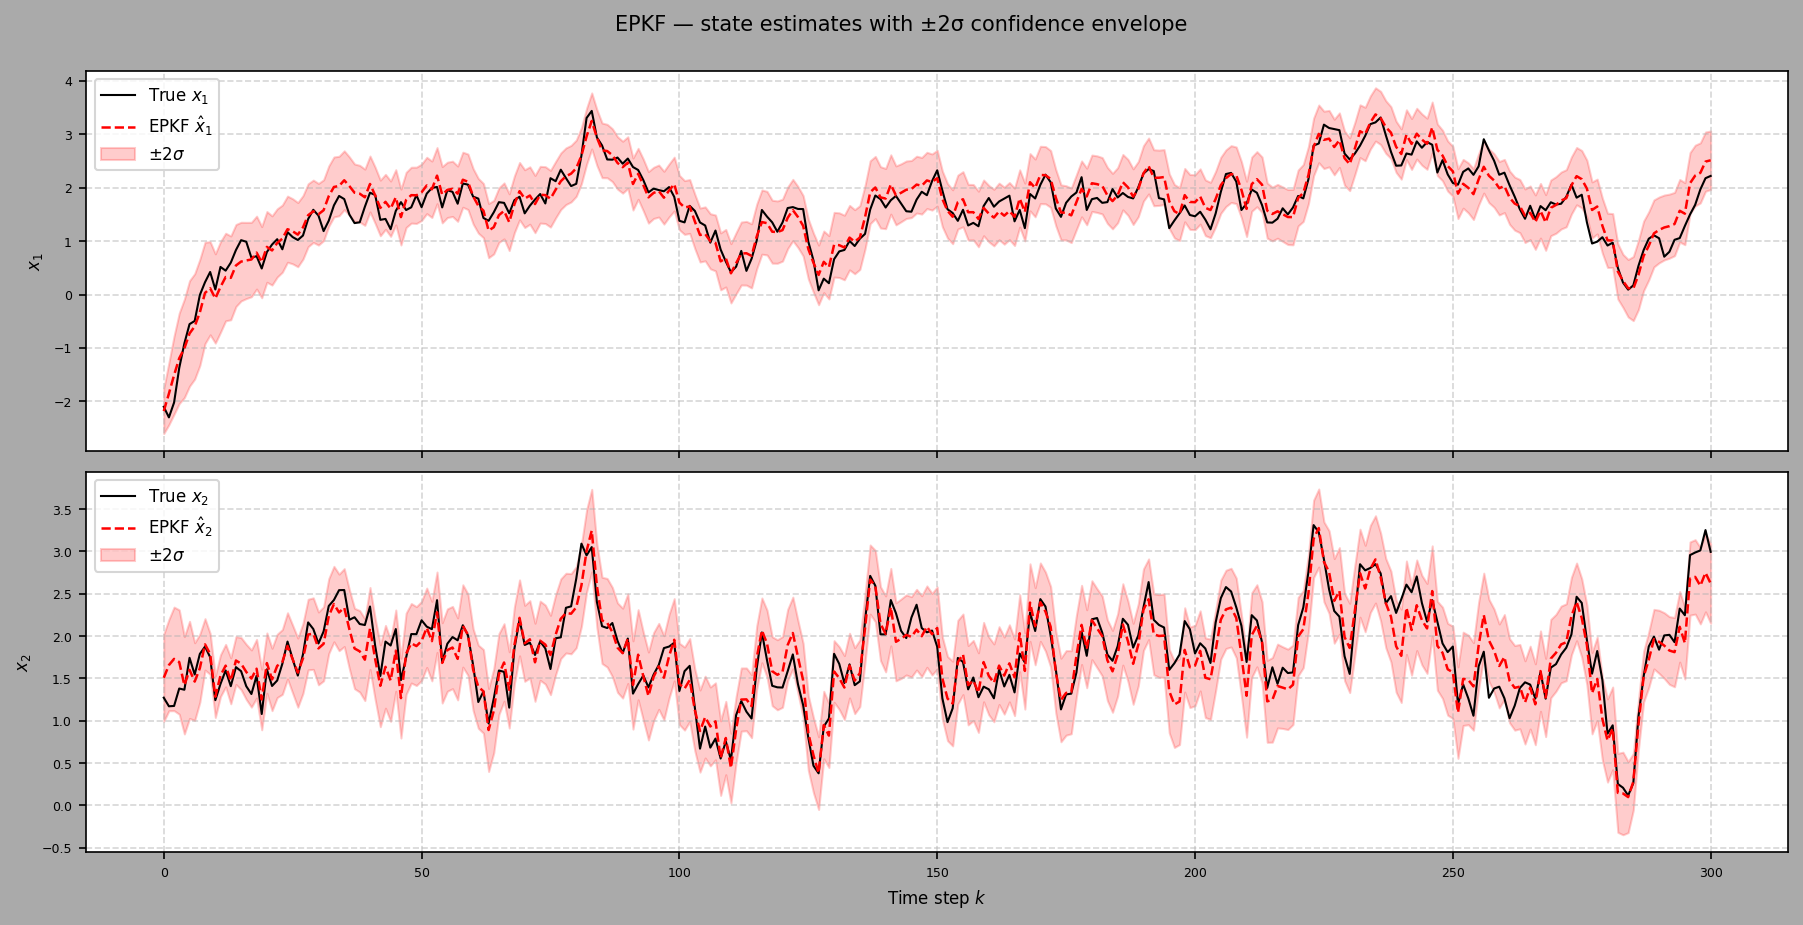

In [6]:
# Extract update covariances
df_epkf = epkf.history.as_dataframe()
P_list  = [v for v in df_epkf["PXXkp1_update"] if v is not None]
P_arr   = np.array(P_list)
std_arr = np.sqrt(np.array([[p[i, i] for i in range(dim_x)] for p in P_arr]))

M = len(xu_epkf)
t = np.arange(M)

fig, axes = plt.subplots(dim_x, 1, figsize=(12, 3 * dim_x), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t, xt_epkf[:, i], color="black", lw=1.0, label=f"True $x_{i+1}$")
    ax.plot(t, xu_epkf[:, i], color="C0",    lw=1.2, label=f"EPKF $\\hat{{x}}_{i+1}$")
    ax.fill_between(t,
        xu_epkf[:, i] - 2 * std_arr[:, i],
        xu_epkf[:, i] + 2 * std_arr[:, i],
        color="C0", alpha=0.2, label=r"$\pm 2\sigma$")
    ax.set_ylabel(f"$x_{i+1}$"); ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.5)
axes[-1].set_xlabel("Time step $k$")
fig.suptitle("EPKF — state estimates with ±2σ confidence envelope", y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Unscented Pairwise Kalman Filter (UPKF)

The UPKF propagates a set of **sigma points** through the nonlinear functions instead of using Jacobians. Several sigma-point sets are available:

| Key | Description |
|-----|-------------|
| `wan2000` | Wan & van der Merwe (2000) — scaled unscented transform |
| `cpkf` | Cubature Kalman Filter (Arasaratnam & Haykin, 2009) |
| `lerner2002` | Lerner (2002) — 5th-order spherical-radial rule |
| `ito2000` | Ito & Xiong (2000) — Gauss-Hermite quadrature |

In [7]:
sigma_sets = ["wan2000", "cpkf", "lerner2002", "ito2000"]

results_upkf = {}
for ss in sigma_sets:
    flt = NonLinear_UPKF(param_classic, sigmaSet=ss, sKey=SEED)
    res = flt.process_N_data(N=N)
    xt, xu = extract(res)
    results_upkf[ss] = (xt, xu)
    print(f"UPKF [{ss:12s}]  MSE = {mse(xt, xu):.6f}")

UPKF [wan2000     ]  MSE = 0.048694
UPKF [cpkf        ]  MSE = 0.048651
UPKF [lerner2002  ]  MSE = 0.048886
UPKF [ito2000     ]  MSE = 0.047459


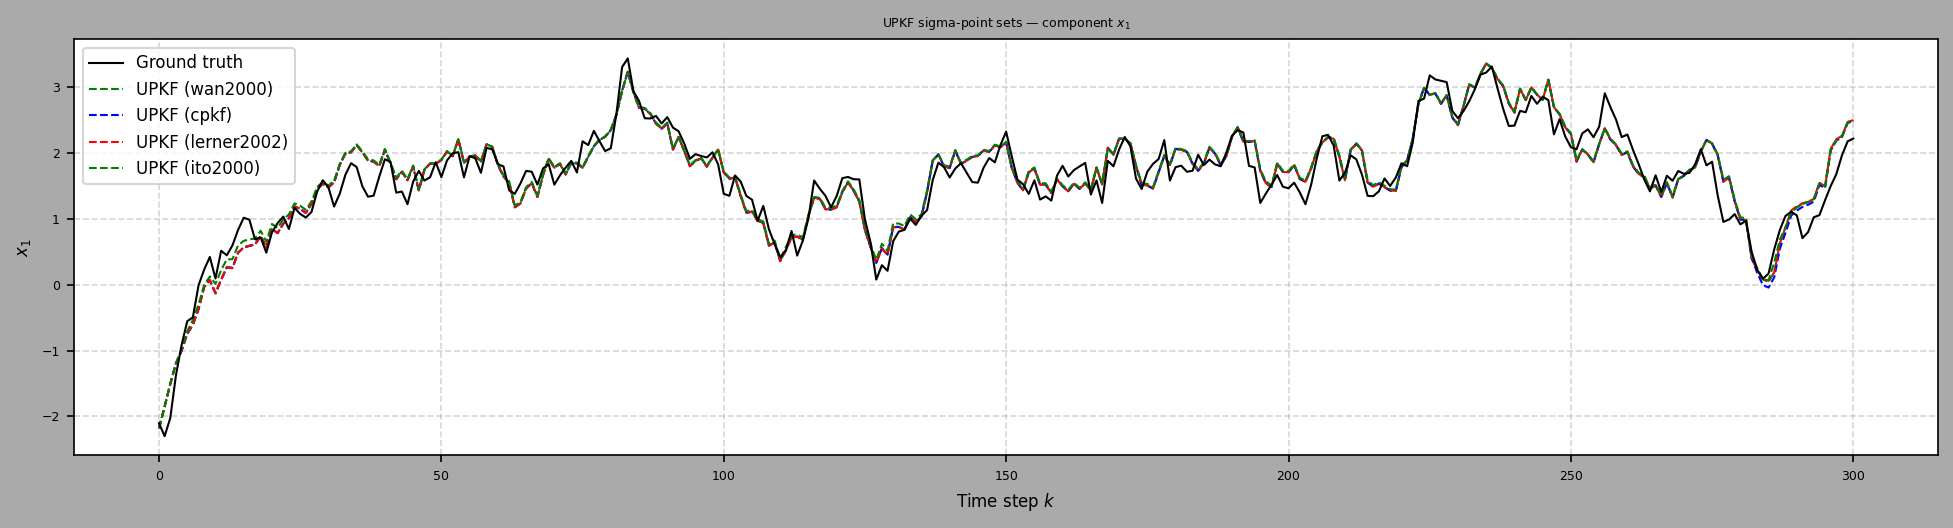

In [8]:
# Visual comparison of sigma-point sets on component x1
colors = ["C1", "C2", "C3", "C4"]

fig, ax = plt.subplots(figsize=(13, 3.5))
xt_ref = results_upkf[sigma_sets[0]][0]
ax.plot(t, xt_ref[:, 0], color="black", lw=1.0, label="Ground truth", zorder=5)
for ss, c in zip(sigma_sets, colors):
    xu = results_upkf[ss][1]
    ax.plot(t, xu[:, 0], color=c, lw=1.0, linestyle="--", label=f"UPKF ({ss})")
ax.set_xlabel("Time step $k$")
ax.set_ylabel("$x_1$")
ax.set_title("UPKF sigma-point sets — component $x_1$")
ax.legend(fontsize=8)
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 5. Pairwise Particle Filter (PPF)

The PPF requires a **pairwise model** where the transition function depends on the previous observation $y_k$. We switch to `model_x2_y1_pairwise`.

$$
g_x(x, y) = \begin{pmatrix} a\,x_1 + b\,x_2 + c\tanh(y_1) \\ d\,x_2 + e\sin(y_1) \end{pmatrix}, \qquad
g_y(x, y) = \frac{x_1^2}{1+x_1^2} + f\,y_1
$$

In [9]:
model_pw  = ModelFactoryNonLinear.create("model_x2_y1_pairwise")
param_pw  = make_param(model_pw)

dim_x_pw = model_pw.get_params()["dim_x"]
dim_y_pw = model_pw.get_params()["dim_y"]

print(f"Model: {model_pw}  (pairwise={model_pw.get_params()['pairwiseModel']})")

ppf = NonLinear_PPF(param_pw, n_particles=500, sKey=SEED)
res_ppf = ppf.process_N_data(N=N)

xt_ppf, xu_ppf = extract(res_ppf)
print(f"PPF — {len(res_ppf)} results, MSE = {mse(xt_ppf, xu_ppf):.6f}")

Model: Model_x2_y1_pairwise(dim_x=2, dim_y=1)  (pairwise=True)
PPF — 301 results, MSE = 0.145869


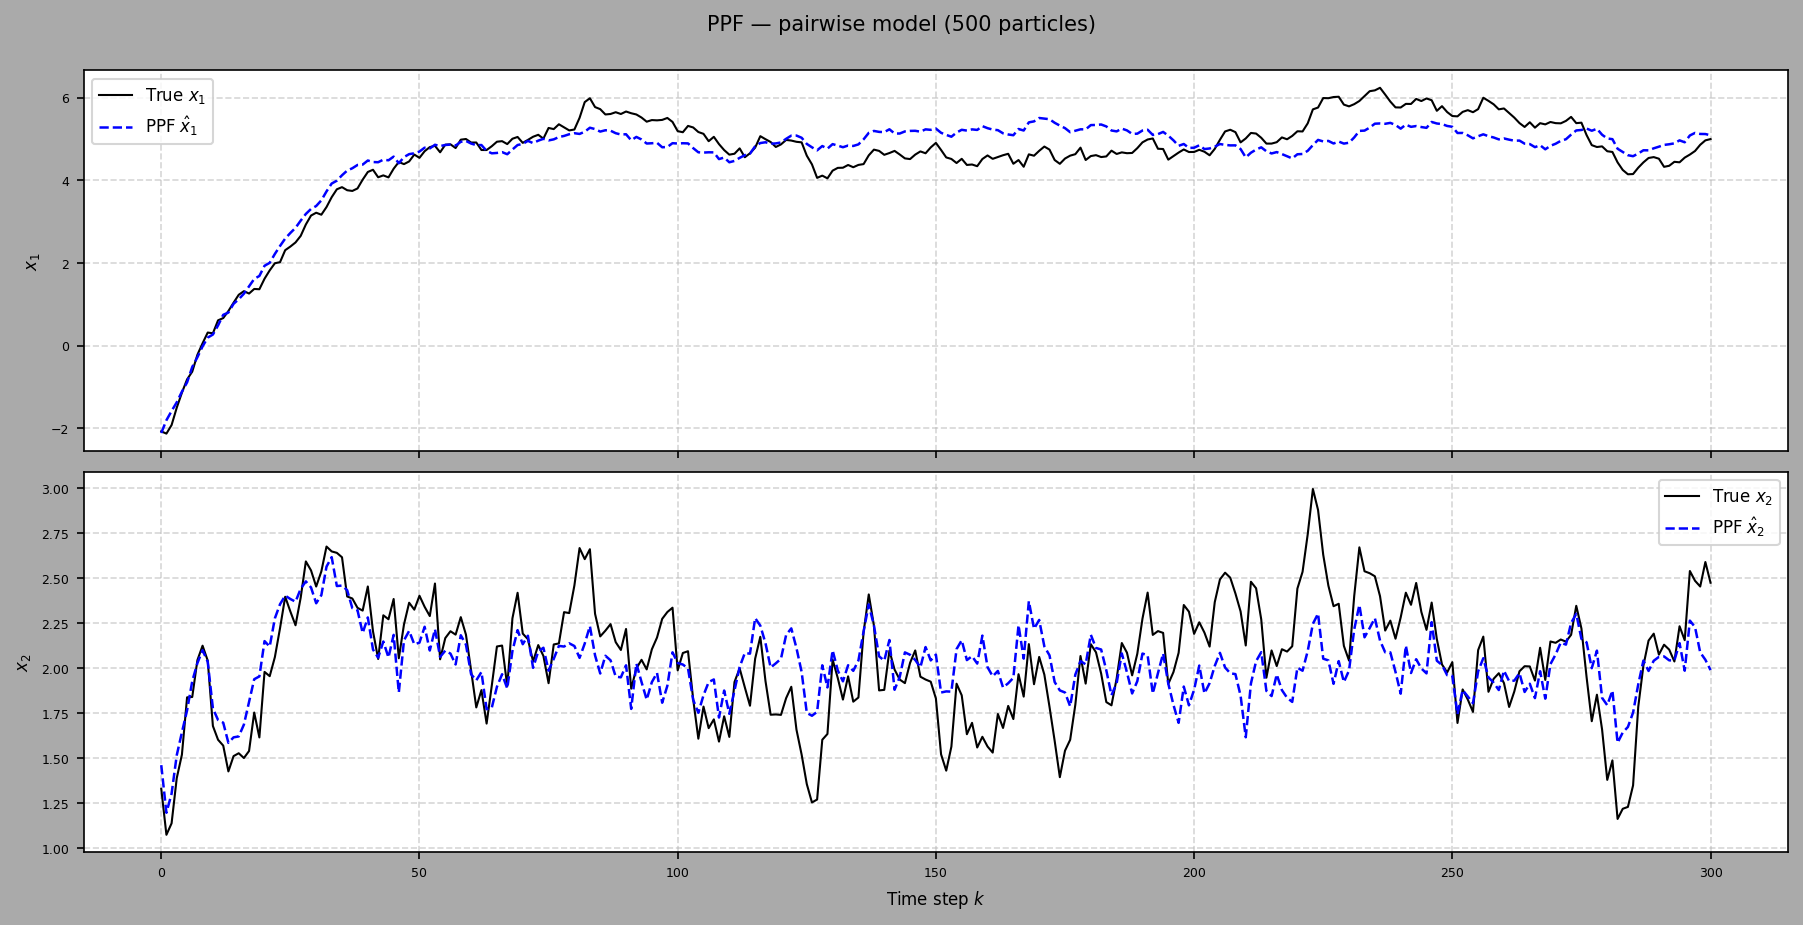

In [10]:
M_pw = len(xu_ppf)
t_pw = np.arange(M_pw)

fig, axes = plt.subplots(dim_x_pw, 1, figsize=(12, 3 * dim_x_pw), sharex=True)
if dim_x_pw == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(t_pw, xt_ppf[:, i], color="black", lw=1.0, label=f"True $x_{i+1}$")
    ax.plot(t_pw, xu_ppf[:, i], color="C5",    lw=1.2, label=f"PPF $\\hat{{x}}_{i+1}$")
    ax.set_ylabel(f"$x_{i+1}$"); ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.5)
axes[-1].set_xlabel("Time step $k$")
fig.suptitle("PPF — pairwise model (500 particles)", y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Bootstrap Particle Filter (PF)

The standard PF works with both classic and pairwise models. It uses **importance sampling** with prior as proposal distribution. The key trade-off is accuracy vs computation time as a function of `n_particles`.

In [11]:
# Run PF on the classic model for several particle counts
particle_counts = [50, 200, 500, 1000]
results_pf = {}

for np_ in particle_counts:
    flt = NonLinear_PF(param_classic, n_particles=np_, sKey=SEED)
    res = flt.process_N_data(N=N)
    xt, xu = extract(res)
    results_pf[np_] = (xt, xu)
    print(f"PF [n_particles={np_:5d}]  MSE = {mse(xt, xu):.6f}")

PF [n_particles=   50]  MSE = 0.071059
PF [n_particles=  200]  MSE = 0.056114
PF [n_particles=  500]  MSE = 0.055077
PF [n_particles= 1000]  MSE = 0.051410


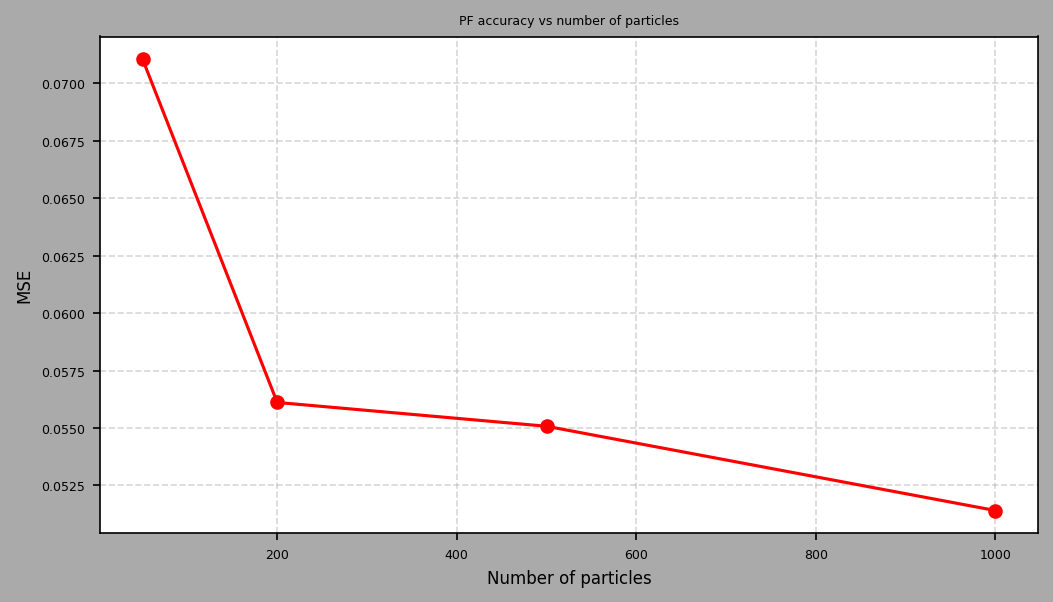

In [12]:
# MSE vs n_particles
nps  = list(results_pf.keys())
mses = [mse(xt, xu) for xt, xu in results_pf.values()]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(nps, mses, "o-", color="C6", lw=1.5)
ax.set_xlabel("Number of particles")
ax.set_ylabel("MSE")
ax.set_title("PF accuracy vs number of particles")
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 7. Filter Comparison on the Same Trajectory

We simulate data once with the **classic model** and run EPKF, UPKF (wan2000), and PF on the same trajectory.

In [13]:
# Simulate a shared trajectory
ref = NonLinear_EPKF(param_classic, sKey=SEED)
sim_data = ref.simulate_N_data(N)

epkf_cmp = NonLinear_EPKF(param_classic, sKey=SEED)
upkf_cmp = NonLinear_UPKF(param_classic, sigmaSet="wan2000", sKey=SEED)
pf_cmp   = NonLinear_PF(param_classic, n_particles=500, sKey=SEED)

res_e = epkf_cmp.process_N_data(N=None, data_generator=iter(sim_data))
res_u = upkf_cmp.process_N_data(N=None, data_generator=iter(sim_data))
res_p = pf_cmp.process_N_data(N=None, data_generator=iter(sim_data))

xt_e, xu_e = extract(res_e)
xt_u, xu_u = extract(res_u)
xt_p, xu_p = extract(res_p)

print("MSE comparison (same trajectory, classic model):")
print(f"  EPKF            : {mse(xt_e, xu_e):.6f}")
print(f"  UPKF (wan2000)  : {mse(xt_u, xu_u):.6f}")
print(f"  PF (500 part.)  : {mse(xt_p, xu_p):.6f}")

MSE comparison (same trajectory, classic model):
  EPKF            : 0.048410
  UPKF (wan2000)  : 0.048694
  PF (500 part.)  : 0.053037


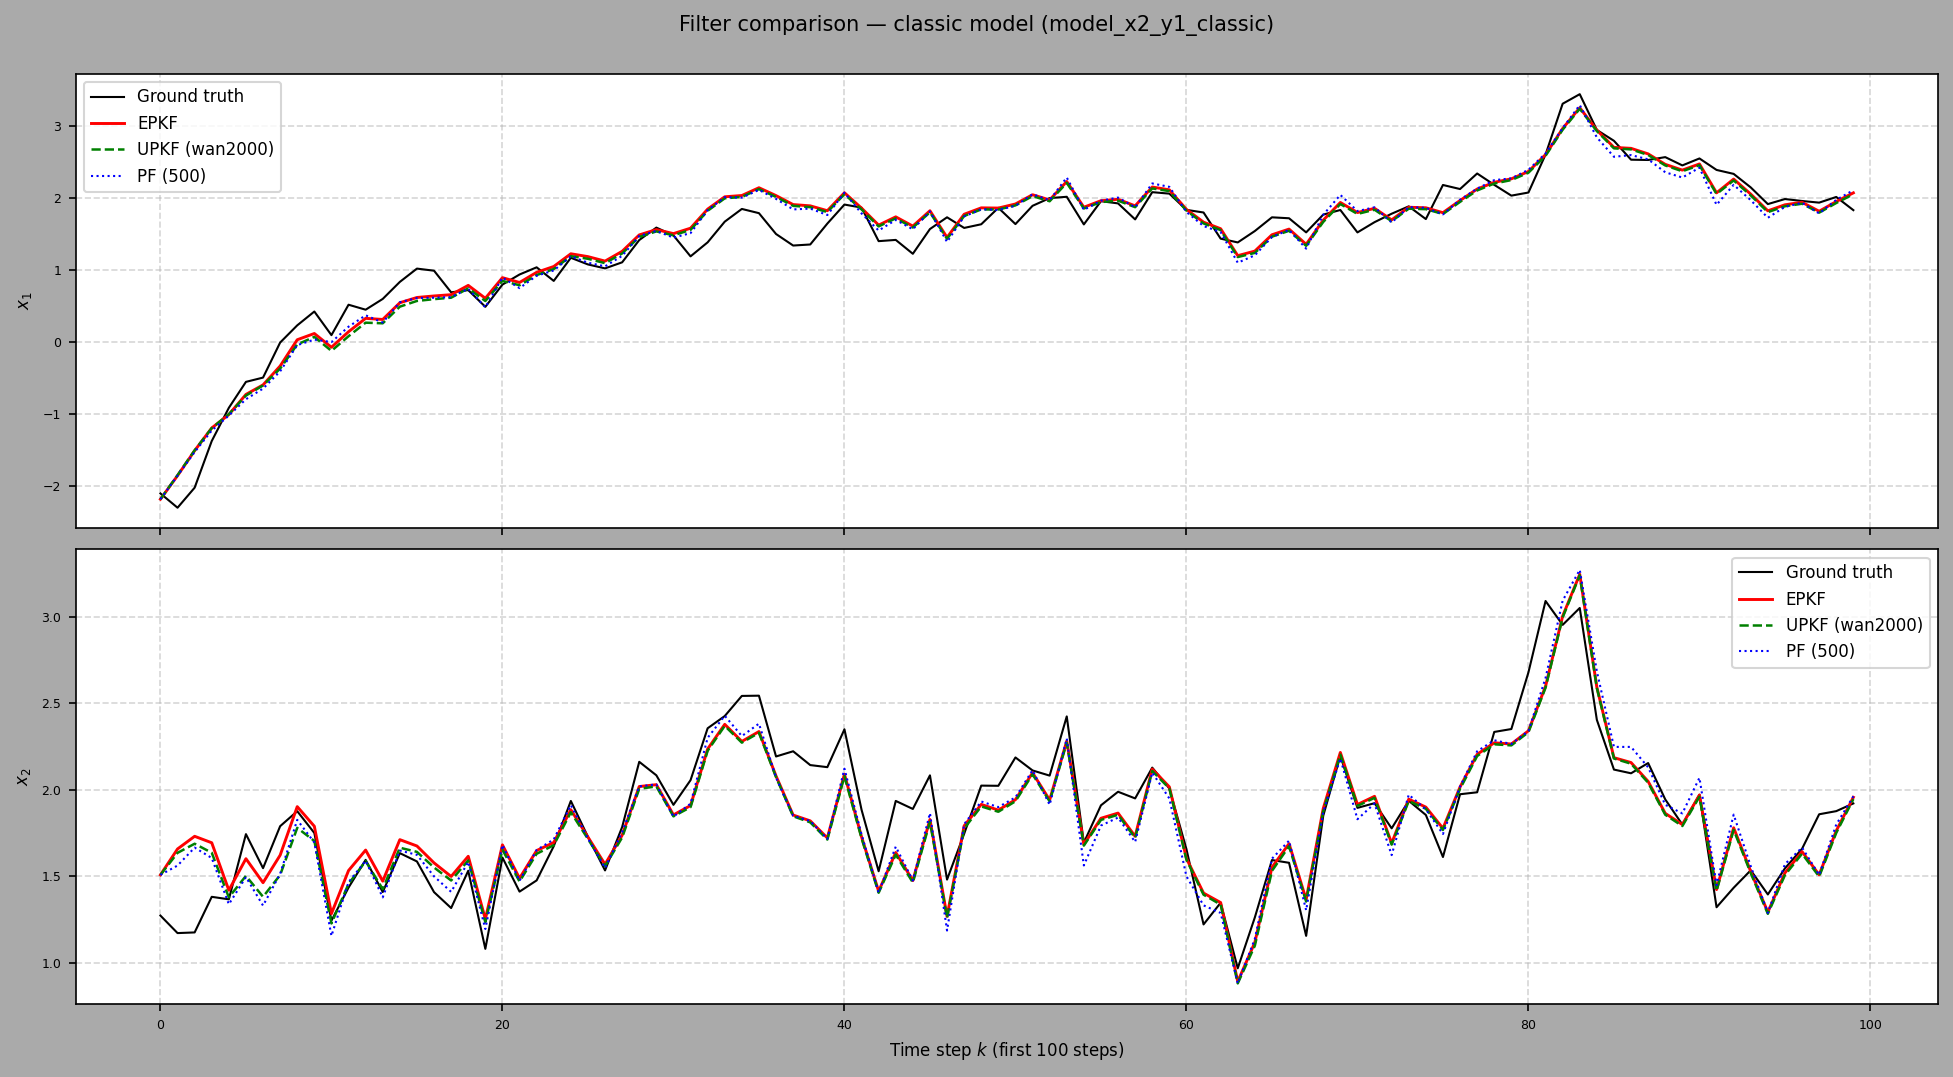

In [14]:
T_WIN = slice(0, 100)
M_cmp = min(len(xu_e), len(xu_u), len(xu_p))
t_cmp = np.arange(M_cmp)

fig, axes = plt.subplots(dim_x, 1, figsize=(13, 3.5 * dim_x), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t_cmp[T_WIN], xt_e[T_WIN, i],  color="black", lw=1.0, label="Ground truth")
    ax.plot(t_cmp[T_WIN], xu_e[T_WIN, i],  color="C0",    lw=1.4, ls="-",  label="EPKF")
    ax.plot(t_cmp[T_WIN], xu_u[T_WIN, i],  color="C1",    lw=1.2, ls="--", label="UPKF (wan2000)")
    ax.plot(t_cmp[T_WIN], xu_p[T_WIN, i],  color="C5",    lw=1.0, ls=":",  label="PF (500)")
    ax.set_ylabel(f"$x_{i+1}$"); ax.legend(fontsize=8); ax.grid(True, ls="--", alpha=0.5)
axes[-1].set_xlabel("Time step $k$ (first 100 steps)")
fig.suptitle("Filter comparison — classic model (model_x2_y1_classic)", y=1.01)
plt.tight_layout()
plt.show()

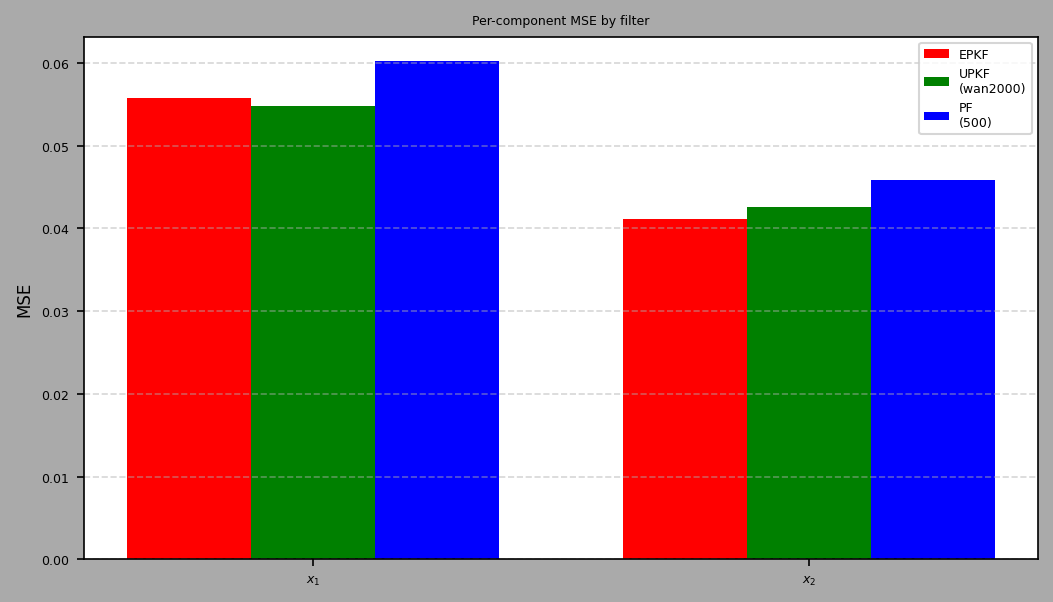

In [15]:
# Per-component MSE bar chart
labels   = [f"$x_{i+1}$" for i in range(dim_x)]
filters  = {"EPKF": (xt_e, xu_e), "UPKF\n(wan2000)": (xt_u, xu_u), "PF\n(500)": (xt_p, xu_p)}
colors_b = ["C0", "C1", "C5"]

x_pos = np.arange(dim_x)
w     = 0.25
fig, ax = plt.subplots(figsize=(7, 4))
for k, ((name, (xt, xu)), c) in enumerate(zip(filters.items(), colors_b)):
    vals = [float(np.mean((xt[:, i] - xu[:, i]) ** 2)) for i in range(dim_x)]
    ax.bar(x_pos + (k - 1) * w, vals, w, label=name, color=c)
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_ylabel("MSE"); ax.set_title("Per-component MSE by filter")
ax.legend(); ax.grid(True, axis="y", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## 8. Going Further

| Task | How |
|------|-----|
| Try a 1D nonlinear model | `ModelFactoryNonLinear.create("model_x1_y1_gordon_classic")` |
| Try the augmented model variant | `ModelFactoryNonLinear.create("model_x2_y1_augmented")` |
| Compare EPKF with UPKF on a pairwise model | Replace `model_x2_y1_classic` with `model_x2_y1_pairwise` |
| Increase particle count for PF | `NonLinear_PF(param, n_particles=2000)` |
| Run PPF on a 2D observation model | `ModelFactoryNonLinear.create("model_x2_y2_pairwise")` |
| Use CLI | `awesomepkf-epkf --nonLinearModelName model_x2_y1_classic --N 500 --plot` |

See `tutorial_03_sigma_points.ipynb` for a deeper dive into sigma-point sets and their impact on UPKF accuracy.